In [62]:
import rasterio
import xarray as xr
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt


In [63]:
# import raster files
msa_file = '../gis/msa/msaUS_mland_aea1_M1.shp'
msa_ds=gpd.read_file(msa_file)

year_month = '200101'
nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'

In [65]:
# get raster value count by range
raster_file = nee_file
with rasterio.open(raster_file) as src:
    raster_data = src.read(1)  # Read the first band
    raster_data = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

    
valid_values = raster_data[~np.isnan(raster_data)]
counts = {}
bounds = [(-10000000, -100), (-100, -10), (-10, -1), (-1, 0), (0, 0.00001), (0.00001, 1), (1, 10), (10, 100), (100, 10000000)] 
for lower, upper in bounds:
    counts[(lower, upper)] = np.sum((valid_values >= lower) & (valid_values < upper))

counts

{(-10000000, -100): np.int64(275),
 (-100, -10): np.int64(2334),
 (-10, -1): np.int64(91136),
 (-1, 0): np.int64(8559144),
 (0, 1e-05): np.int64(9195694),
 (1e-05, 1): np.int64(19534415),
 (1, 10): np.int64(1101530),
 (10, 100): np.int64(20103),
 (100, 10000000): np.int64(614)}

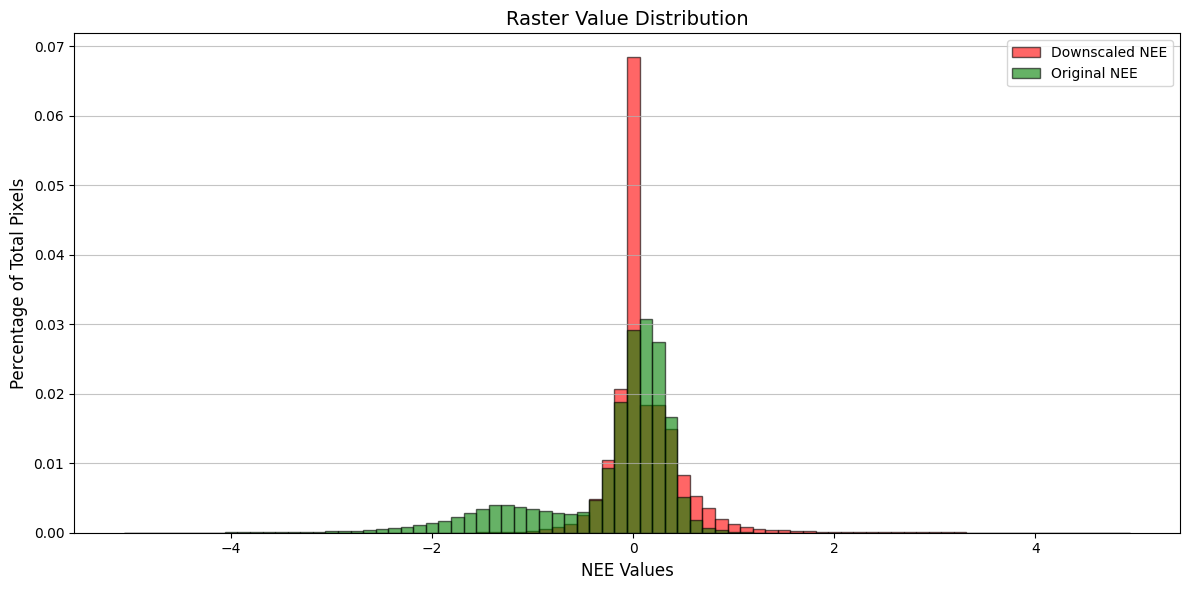

In [ ]:
# Plot the pixel count / pixel number histograms
bins=80
title="Raster Value Distribution"
year_month = '200101'
x_min = -5
x_max = 5


downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
original_nee_file = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

with rasterio.open(downscaled_nee_file) as src:
    downscaled_nee = src.read(1)  # Read the first band
    downscaled_nee = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

variable = 'NEE'
ds = xr.open_dataset(original_nee_file)
original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

valid_downscaled = downscaled_nee[(~np.isnan(downscaled_nee))]
valid_original = original_nee[(~np.isnan(original_nee))]

# Calculate total number of pixels in the raster
total_pixels_downscaled = downscaled_nee.size  # Total pixels (rows * cols)
total_pixels_original = original_nee.size

# Compute histograms
hist_downscaled, bin_edges = np.histogram(valid_downscaled, bins=bins, range=(x_min, x_max))
hist_original, _ = np.histogram(valid_original, bins=bins, range=(x_min, x_max))

# Convert counts to percentages
hist_downscaled_percentage = hist_downscaled / total_pixels_downscaled
hist_original_percentage = hist_original / total_pixels_original

# Plot histogram with correct percentages
plt.figure(figsize=(12, 6))
plt.bar(bin_edges[:-1], hist_downscaled_percentage, width=np.diff(bin_edges), color='red', alpha=0.6, edgecolor='black', label='Downscaled NEE')
plt.bar(bin_edges[:-1], hist_original_percentage, width=np.diff(bin_edges), color='green', alpha=0.6, edgecolor='black', label='Original NEE')

plt.title(title, fontsize=14)
plt.xlabel('NEE Values', fontsize=12)
plt.ylabel('Percentage of Total Pixels', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


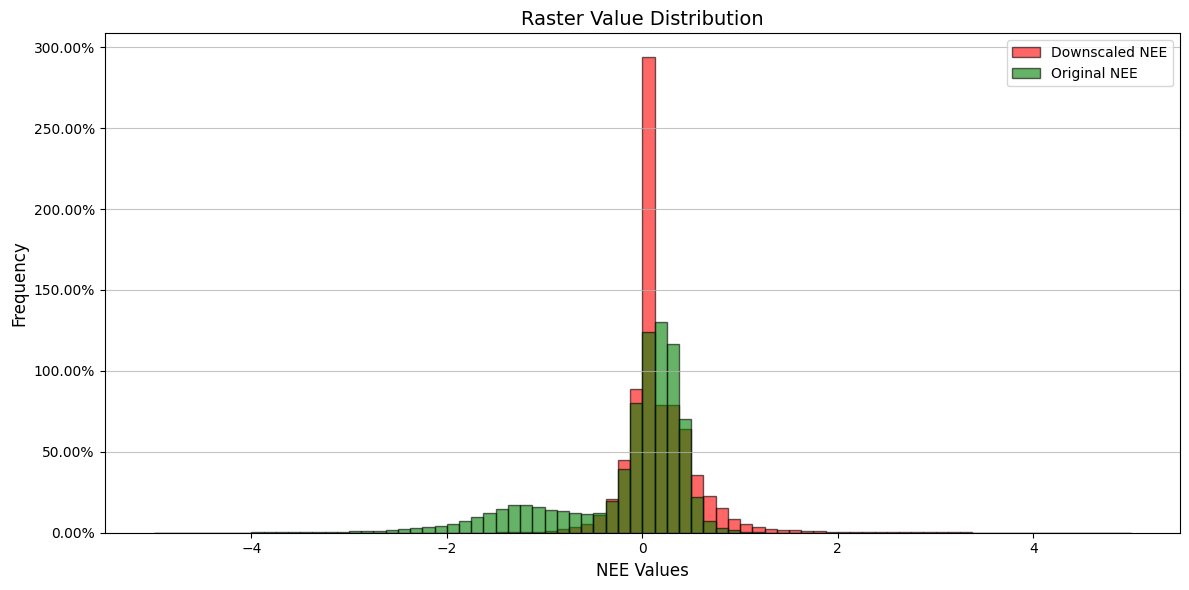

In [ ]:

bins=80
title="Raster Value Distribution"
year_month = '200101'

downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
original_nee_file = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

with rasterio.open(downscaled_nee_file) as src:
    downscaled_nee = src.read(1)  # Read the first band
    downscaled_nee = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

variable = 'NEE'
ds = xr.open_dataset(original_nee_file)
original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

valid_downscaled = downscaled_nee[(~np.isnan(downscaled_nee))]
valid_original = original_nee[(~np.isnan(original_nee))]

x_min = -5
x_max = 5

# Plot the pixel count histograms
plt.figure(figsize=(12, 6))
plt.hist(valid_downscaled, bins=bins, range=(x_min, x_max), density=True, color='red', alpha=0.6, edgecolor='black', label='Downscaled NEE')
plt.hist(valid_original, bins=bins, range=(x_min, x_max), density=True, color='green', alpha=0.6, edgecolor='black', label='Original NEE')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y * 100:.2f}%')) # Convert density to percentage

plt.title(title, fontsize=14)
plt.xlabel('NEE Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

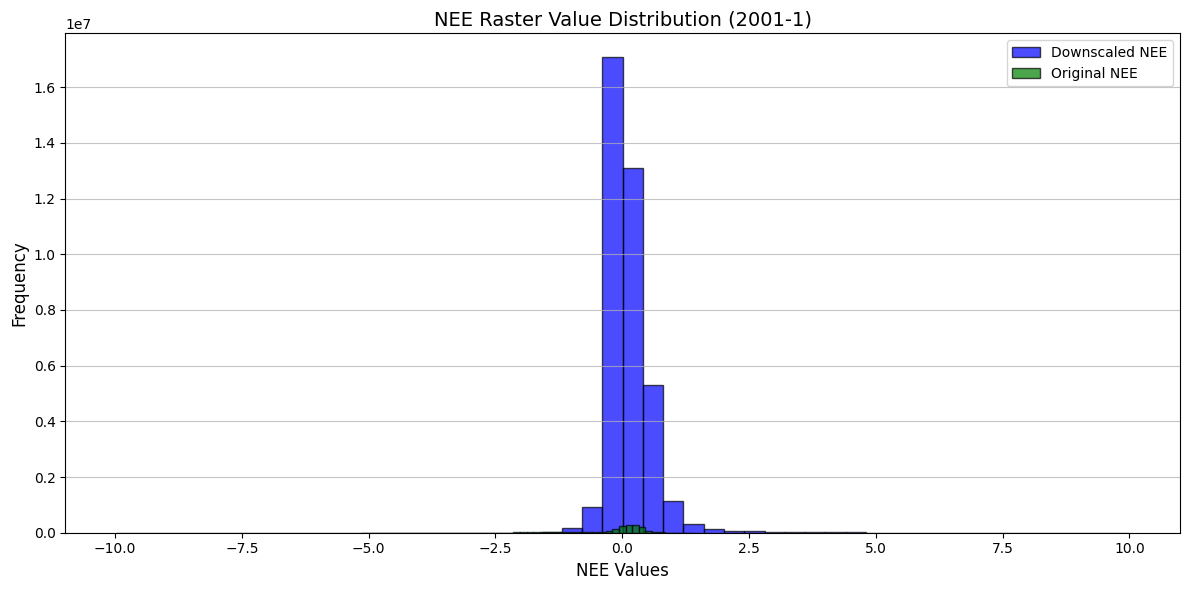

In [30]:


def plot_histogram_within_range(year_month, valid_values, bins=50, title="Raster Value Distribution"):
    """
    Plots a histogram of raster values within a specified range.

    Parameters:
        year_month(str): e.g. '200101'
        raster_file (str): Path to the raster file.
        value_range (tuple): Range of values to include in the histogram (min, max).
        bins (int): Number of bins for the histogram (default is 50).
        title (str): Title for the histogram plot.
        year (int): Year of the data.
        month (int): Month of the data.

    Returns:
        None: Displays the histogram.
    """
    
    downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
    original_nee_file = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

    with rasterio.open(downscaled_nee_file) as src:
        downscaled_nee = src.read(1)  # Read the first band
        downscaled_nee = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

    variable = 'NEE'
    ds = xr.open_dataset(original_nee_file)
    original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

    min_val, max_val = value_range

    valid_downscaled = downscaled_nee[(~np.isnan(downscaled_nee)) & (downscaled_nee >= min_val) & (downscaled_nee <= max_val)]
    valid_original = original_nee[(~np.isnan(original_nee)) & (original_nee >= min_val) & (original_nee <= max_val)]

    # Plot the histograms
    plt.figure(figsize=(12, 6))
    plt.hist(valid_downscaled, bins=bins, color='blue', alpha=0.7, edgecolor='black', label='Downscaled NEE')
    plt.hist(valid_original, bins=bins, color='green', alpha=0.7, edgecolor='black', label='Original NEE')
    plt.title(title, fontsize=14)
    plt.xlabel('NEE Values', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
    
    # # Plot the histogram
    # plt.figure(figsize=(10, 6))
    # plt.hist(valid_values, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    # plt.title(title, fontsize=14)
    # plt.xlabel('Raster value', fontsize=12)
    # plt.ylabel('Pixel count', fontsize=12)
    # plt.grid(axis='y', alpha=0.75)
    # plt.tight_layout()
    # plt.show()

# year = 2001
# month = 1
year_month = '200101'
value_range = (-10, 10)  # Specify the range of values to include in the histogram
plot_histogram_within_range(year_month, valid_values, bins=50, title=f"NEE Raster Value Distribution ({str(year)}-{str(month)})")


In [51]:
max(valid_downscaled)

np.float32(0.9999873)

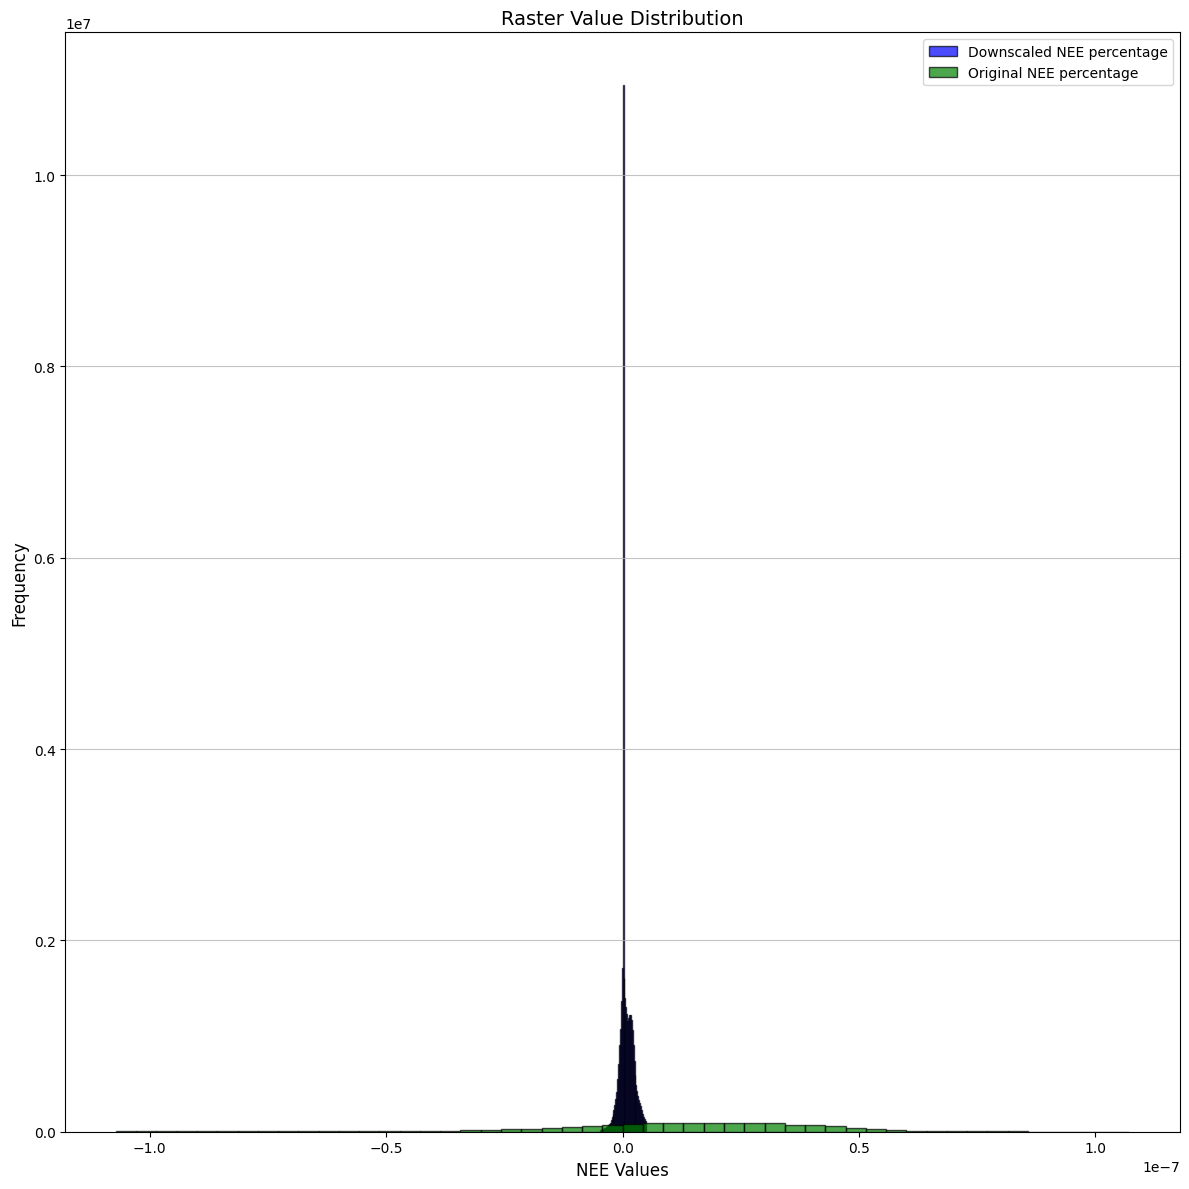

In [47]:
# Plot the pixel percentage histograms

# raster_area_ratio = (len(downscaled_nee) * len(downscaled_nee[0])) / (len(original_nee) * len(original_nee[0]))
valid_downscaled_perc = valid_downscaled / (len(downscaled_nee) * len(downscaled_nee[0]))
# valid_original = original_nee[(~np.isnan(original_nee)) & (original_nee >= min_val) & (original_nee <= max_val)]
valid_original_perc = valid_original / (len(original_nee) * len(original_nee[0]))


plt.figure(figsize=(12, 12))
plt.hist(valid_downscaled_perc, bins=bins, color='blue', alpha=0.7, edgecolor='black', label='Downscaled NEE percentage')
plt.hist(valid_original_perc, bins=bins, color='green', alpha=0.7, edgecolor='black', label='Original NEE percentage')
plt.title(title, fontsize=14)
plt.xlabel('NEE Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [42]:
valid_downscaled_perc

array([3.6241408e-09, 1.8559740e-09, 0.0000000e+00, ..., 1.5029079e-09,
       1.4759499e-09, 1.3613785e-09], dtype=float32)

In [38]:
print

9331200


In [39]:
print(len(downscaled_nee) * len(downscaled_nee[0]))

206291258


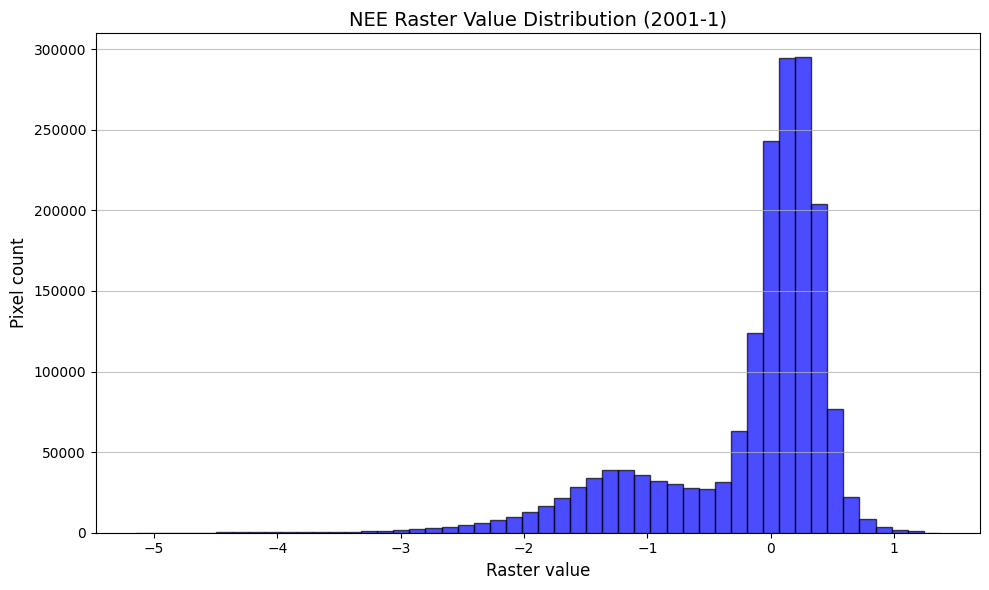

In [26]:
nee_raw_file = f"../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year}.nc"
plot_histogram_within_range(nee_raw_file, value_range, year, month, bins=50, title=f"NEE Raster Value Distribution ({str(year)}-{str(month)})")



In [ ]:


value_range = (-5, 5) 
plot_histogram_within_range(nee_raw_file, value_range, bins=50, title="NEE Raster Value Distribution (-10 to 50)")

In [ ]:
year_month = '200101'
nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
with rasterio.open(nee_file) as nee_dstrd:
    for index, record in msa_ds.iterrows():
        msa_name = record['NAMELSAD']
        # print(f'Generating downscaled data for {msa_name}...')
        msa = msa_ds.loc[[index]]

